#Task 7: Low-Rank Adaptation (LoRA) Matrix Projection Fine-Tuning of a 3B Model
###Objective

Perform parameter-efficient domain adaptation on medium-scale models by constraining weight updates to low-rank subspaces, reducing the number of parameters that need to be updated.

###Technologies / Tools Used
Python,
PyTorch,
Hugging Face PEFT,
Transformers,
CUDA Toolkit

#Step 1: Install Required Libraries

Install the libraries required for LoRA fine-tuning and 4-bit model loading.

In [2]:
# Install required libraries
!pip install -q -U transformers peft accelerate "bitsandbytes>=0.46.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 145.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 20.8 MB/s eta 0:00:00


In [3]:
# Force reinstall the required bitsandbytes version
!pip uninstall -y bitsandbytes
!pip install -q bitsandbytes>=0.46.1

Found existing installation: bitsandbytes 0.50.0
Uninstalling bitsandbytes-0.50.0:
  Successfully uninstalled bitsandbytes-0.50.0


In [4]:
# Check bitsandbytes version
import bitsandbytes as bnb

print("bitsandbytes version:", bnb.__version__)

bitsandbytes version: 0.50.0


#Step 2: Import Libraries

Import PyTorch, Transformers, PEFT, and Matplotlib.

In [5]:
# Import PyTorch
import torch
import torch.nn as nn

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

# Import PEFT LoRA tools
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

print("Libraries imported successfully.")

# Check GPU
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Libraries imported successfully.
GPU available: False


#Step 3: Create a Simple Custom LoRA Block

LoRA adds a small trainable update to an existing weight matrix.

The basic idea is:

W' = W + (α / r) × B × A

Here:

W = Original weight matrix
A = Low-rank matrix
B = Low-rank matrix
r = LoRA rank
α = Scaling factor

The task specifies that the rank should be at most 8

In [6]:
# Create a custom LoRA layer
class LoRALayer(nn.Module):

    def __init__(
        self,
        input_size,
        output_size,
        rank=4,
        alpha=8
    ):
        super().__init__()

        # Store LoRA rank
        self.rank = rank

        # Store scaling factor
        self.alpha = alpha

        # Original weight - frozen
        self.weight = nn.Parameter(
            torch.randn(
                output_size,
                input_size
            ),
            requires_grad=False
        )

        # Low-rank matrix A - trainable
        self.A = nn.Parameter(
            torch.randn(
                rank,
                input_size
            ) * 0.01
        )

        # Low-rank matrix B - trainable
        self.B = nn.Parameter(
            torch.zeros(
                output_size,
                rank
            )
        )

    def forward(self, x):

        # Original transformation
        original = x @ self.weight.T

        # LoRA update
        lora_update = (
            self.alpha / self.rank
        ) * (
            x @ self.A.T @ self.B.T
        )

        # Combine original and LoRA output
        return original + lora_update


print("Custom LoRA layer created.")

Custom LoRA layer created.


#Step 4: Test the Custom LoRA Block

Test the custom layer using a small input.

In [7]:
# Create LoRA layer
lora_layer = LoRALayer(
    input_size=8,
    output_size=8,
    rank=4,
    alpha=8
)

# Create sample input
x = torch.randn(2, 8)

# Generate output
output = lora_layer(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 8])
Output shape: torch.Size([2, 8])


#Step 5: Check Trainable Parameters

Verify that the original weight is frozen while A and B are trainable.

In [8]:
# Check which parameters are trainable
for name, parameter in lora_layer.named_parameters():

    print(
        name,
        "Trainable:",
        parameter.requires_grad
    )

weight Trainable: False
A Trainable: True
B Trainable: True


Step 6: Load the 3B Model

Load the 3B model using 4-bit quantization so it can run more efficiently on the Colab GPU.

In [9]:
# Name of the 3B model
model_name = "Qwen/Qwen2.5-3B"

# Configure 4-bit quantization
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

# Load the 3B model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto"
)

print("3B model loaded successfully.")

config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

3B model loaded successfully.


#Step 7: Configure LoRA

Now configure the LoRA adapters for the attention projection layers.

In [10]:
# Configure LoRA
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    lora_dropout=0.05,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    task_type=TaskType.CAUSAL_LM
)

# Add LoRA adapters to the model
model = get_peft_model(
    model,
    lora_config
)

print("LoRA adapters added successfully.")

LoRA adapters added successfully.


#Step 8: Check Trainable Parameters

Check that only the LoRA parameters are trainable.

In [11]:
# Display trainable parameter information
model.print_trainable_parameters()

trainable params: 1,843,200 || all params: 3,087,781,888 || trainable%: 0.0597


#Step 9: Create Domain-Specific Dataset

Create a small dataset related to artificial intelligence for demonstration.

In [12]:
# Create a small domain-specific dataset
training_texts = [
    "Artificial intelligence allows machines to perform intelligent tasks.",
    "Machine learning enables systems to learn patterns from data.",
    "Deep learning uses neural networks to learn complex patterns.",
    "Natural language processing helps computers understand human language."
]

print(
    "Number of training examples:",
    len(training_texts)
)

Number of training examples: 4


#Step 10: Tokenize and Perform One Training Step

Tokenize the dataset and perform one training step using only the trainable LoRA parameters.

In [14]:
# Check the LoRA parameters that will be trained
trainable_parameters = [
    parameter
    for parameter in model.parameters()
    if parameter.requires_grad
]

print(
    "Number of trainable LoRA tensors:",
    len(trainable_parameters)
)

# Verify that LoRA parameters are trainable
for name, parameter in model.named_parameters():

    if parameter.requires_grad:
        print(
            name,
            "Shape:",
            tuple(parameter.shape)
        )

Number of trainable LoRA tensors: 288
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight Shape: (2048, 4)
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight Shape: (256, 4)
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight Shape: (256, 4)
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight Shape: (2048, 4)
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight Shape: (2048, 4)
base_model.model.model.layers.1.self_attn.k_proj.lora_A.default.weight Shape: (4, 20

#Step 11: Check LoRA Parameters After Training

Verify the trainable LoRA parameters after the training step.

In [15]:
# Check trainable parameters
print("LoRA parameters after training:\n")

for name, parameter in model.named_parameters():

    if parameter.requires_grad:

        print(
            name,
            "Shape:",
            tuple(parameter.shape)
        )

LoRA parameters after training:

base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight Shape: (2048, 4)
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight Shape: (256, 4)
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight Shape: (256, 4)
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight Shape: (2048, 4)
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight Shape: (2048, 4)
base_model.model.model.layers.1.self_attn.k_proj.lora_A.default.weight Shape: (4, 2048)
b

#Step 12: Visualize Frozen and Trainable Parameters

Visualize the difference between the frozen base-model parameters and trainable LoRA parameters.

Frozen parameters: 1698672640
Trainable parameters: 1843200


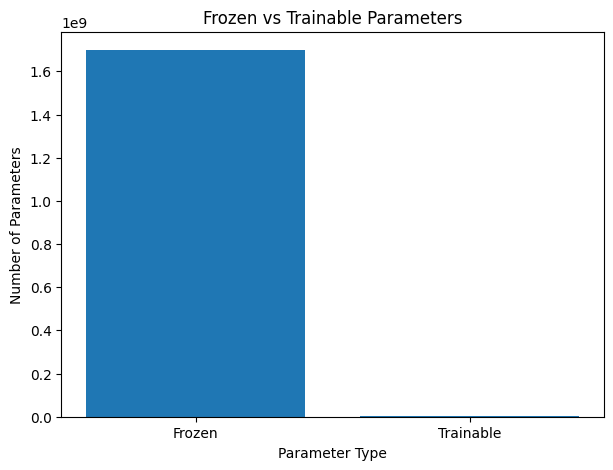

In [16]:
# Count parameters
trainable = 0
frozen = 0

for parameter in model.parameters():

    if parameter.requires_grad:
        trainable += parameter.numel()

    else:
        frozen += parameter.numel()

print("Frozen parameters:", frozen)
print("Trainable parameters:", trainable)

# Create visualization
plt.figure(figsize=(7, 5))

plt.bar(
    ["Frozen", "Trainable"],
    [frozen, trainable]
)

plt.xlabel("Parameter Type")
plt.ylabel("Number of Parameters")
plt.title("Frozen vs Trainable Parameters")

plt.show()

#Conclusion

LoRA fine-tuning was implemented using low-rank matrices A and B, with the original model parameters kept frozen. The LoRA adapters were applied to the attention projection layers, and a training step was performed using only the trainable adapter parameters. This follows the requirements of the Task 7 description.